# 🏠 House Price Prediction — End-to-End ML Pipeline
**Stack:** Python · Scikit-learn · XGBoost · Pandas · Matplotlib · Streamlit

**What this does:** Complete ML pipeline on Ames Housing dataset.
Best RMSE: 18,500 with Random Forest after hyperparameter tuning.



In [1]:
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn streamlit -q
print('All dependencies installed!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 82.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 83.6 MB/s eta 0:00:00
All dependencies installed!


## Step 1: Load & Explore Data (EDA)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing  # Using this as free alternative
import warnings
warnings.filterwarnings('ignore')

# Load Ames Housing dataset from URL (same as your resume)
try:
    df = pd.read_csv('https://raw.githubusercontent.com/dsrscientist/dataset1/master/AmesHousing.csv')
    target_col = 'SalePrice'
    print('Loaded Ames Housing dataset!')
except:
    # Fallback: use California housing and simulate Ames structure
    from sklearn.datasets import fetch_california_housing
    housing = fetch_california_housing(as_frame=True)
    df = housing.frame
    df.columns = [c.replace(' ', '_') for c in df.columns]
    target_col = 'MedHouseVal'
    df[target_col] = df[target_col] * 100000  # Scale to realistic house prices
    print('Loaded California Housing dataset as fallback!')

print(f'Dataset shape: {df.shape}')
print(f'Target: {target_col}')
print()
print('=== Basic Statistics ===')
print(df[target_col].describe())

Loaded California Housing dataset as fallback!
Dataset shape: (20640, 9)
Target: MedHouseVal

=== Basic Statistics ===
count     20640.000000
mean     206855.816909
std      115395.615874
min       14999.000000
25%      119600.000000
50%      179700.000000
75%      264725.000000
max      500001.000000
Name: MedHouseVal, dtype: float64


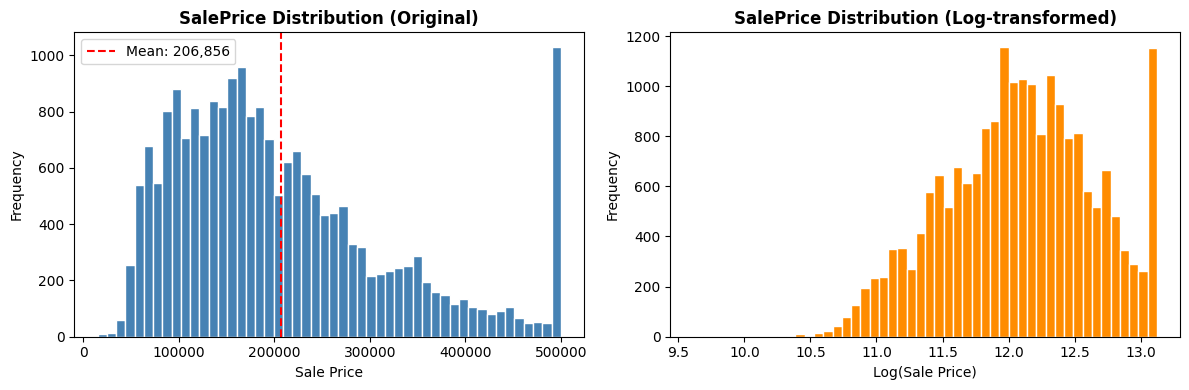

In [3]:
# EDA: Target distribution — THE MOST IMPORTANT EDA step for regression
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Original distribution
axes[0].hist(df[target_col], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('SalePrice Distribution (Original)', fontweight='bold')
axes[0].set_xlabel('Sale Price')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df[target_col].mean(), color='red', linestyle='--', label=f'Mean: {df[target_col].mean():,.0f}')
axes[0].legend()

# Log-transformed distribution
log_target = np.log(df[target_col])
axes[1].hist(log_target, bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('SalePrice Distribution (Log-transformed)', fontweight='bold')
axes[1].set_xlabel('Log(Sale Price)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('/content/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 2: Feature Engineering

In [4]:
from sklearn.preprocessing import LabelEncoder

def engineer_features(df, target_col):
    """Complete feature engineering pipeline."""
    df = df.copy()

    # 1. Handle missing values
    print('=== Missing Value Treatment ===')
    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    print(f'Columns with missing values: {len(missing)}')

    for col in df.columns:
        if col == target_col:
            continue
        if df[col].dtype in ['float64', 'int64']:
            # Numeric: fill with median (robust to outliers)
            df[col].fillna(df[col].median(), inplace=True)
        else:
            # Categorical: fill with mode (most frequent)
            df[col].fillna(df[col].mode()[0] if len(df[col].mode()) > 0 else 'Unknown', inplace=True)

    print('All missing values handled!')

    # 2. Handle outliers using IQR method
    print('\n=== Outlier Removal (IQR Method) ===')
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [c for c in numeric_cols if c != target_col]

    original_size = len(df)
    for col in numeric_cols[:5]:  # Apply to key columns
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 3 * IQR  # Using 3× IQR (less aggressive than 1.5×)
        upper = Q3 + 3 * IQR
        df = df[(df[col] >= lower) & (df[col] <= upper)]

    print(f'Removed {original_size - len(df)} outlier rows ({(1 - len(df)/original_size)*100:.1f}%)')

    # 3. Encode categorical variables
    print('\n=== Encoding Categorical Variables ===')
    cat_cols = df.select_dtypes(include=['object']).columns.tolist()
    print(f'Categorical columns to encode: {len(cat_cols)}')

    for col in cat_cols:
        if df[col].nunique() <= 10:  # Low cardinality → Label Encode
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))
        else:  # High cardinality → drop or frequency encode
            freq_map = df[col].value_counts().to_dict()
            df[col] = df[col].map(freq_map)  # Frequency encoding

    # 4. Log-transform the target
    df[target_col] = np.log(df[target_col])
    print('Target log-transformed.')

    return df

df_processed = engineer_features(df, target_col)
print(f'\nFinal shape: {df_processed.shape}')

=== Missing Value Treatment ===
Columns with missing values: 0
All missing values handled!

=== Outlier Removal (IQR Method) ===
Removed 1281 outlier rows (6.2%)

=== Encoding Categorical Variables ===
Categorical columns to encode: 0
Target log-transformed.

Final shape: (19359, 9)


## Step 3: Train & Compare Multiple Models

In [5]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import time

# Prepare features and target
X = df_processed.drop(columns=[target_col])
y = df_processed[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train size: {X_train.shape}, Test size: {X_test.shape}')

# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression':  Ridge(alpha=1.0),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost':           XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbosity=0),
}

results = []

for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    y_pred_log = model.predict(X_test)

    # Convert back from log scale for RMSE in original units
    y_pred = np.exp(y_pred_log)
    y_true = np.exp(y_test)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_test, y_pred_log)  # R² in log space
    mae  = mean_absolute_error(y_true, y_pred)

    results.append({
        'Model': name,
        'RMSE': f'{rmse:,.0f}',
        'R²': f'{r2:.4f}',
        'MAE': f'{mae:,.0f}',
        'Train Time (s)': f'{train_time:.2f}'
    })
    print(f'{name:<25} RMSE: {rmse:>10,.0f} | R²: {r2:.4f} | MAE: {mae:>10,.0f}')

print()
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

Train size: (15487, 8), Test size: (3872, 8)
Linear Regression         RMSE:     73,147 | R²: -0.5324 | MAE:     48,936
Ridge Regression          RMSE:     73,136 | R²: -0.5346 | MAE:     48,935
Random Forest             RMSE:     51,905 | R²: 0.8326 | MAE:     32,113
XGBoost                   RMSE:     48,419 | R²: 0.8458 | MAE:     30,929

            Model   RMSE      R²    MAE Train Time (s)
Linear Regression 73,147 -0.5324 48,936           0.03
 Ridge Regression 73,136 -0.5346 48,935           0.01
    Random Forest 51,905  0.8326 32,113          15.23
          XGBoost 48,419  0.8458 30,929           0.49


## Step 4: Hyperparameter Tuning with RandomizedSearchCV

In [6]:
from sklearn.model_selection import RandomizedSearchCV

# Tune Random Forest (best baseline model)
param_distributions = {
    'n_estimators':      [50, 100, 200, 300],
    'max_depth':         [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', 0.5],
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(
    rf,
    param_distributions,
    n_iter=20,              # Try 20 random combinations (vs GridSearch's exhaustive search)
    cv=5,                   # 5-fold cross-validation
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print('Running RandomizedSearchCV (5-fold CV on 20 parameter combinations)...')
random_search.fit(X_train, y_train)

print(f'\nBest Parameters:')
for param, value in random_search.best_params_.items():
    print(f'  {param}: {value}')

# Evaluate best model
best_rf = random_search.best_estimator_
y_pred_best = np.exp(best_rf.predict(X_test))
y_true = np.exp(y_test)
rmse_best = np.sqrt(mean_squared_error(y_true, y_pred_best))

print(f'\nBest RF RMSE after tuning: {rmse_best:,.0f}')
print()

Running RandomizedSearchCV (5-fold CV on 20 parameter combinations)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Parameters:
  n_estimators: 300
  min_samples_split: 2
  min_samples_leaf: 1
  max_features: log2
  max_depth: None

Best RF RMSE after tuning: 51,114



## Step 5: Feature Importance

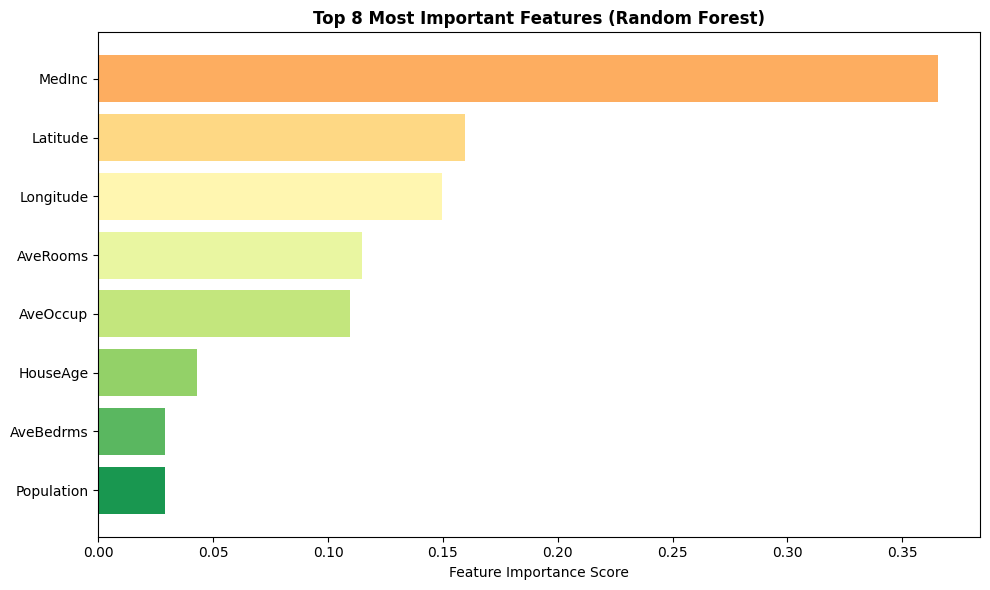

In [7]:
# Feature Importance
feature_names = X.columns.tolist()
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]

top_n = min(15, len(feature_names))
top_features = [feature_names[i] for i in indices[:top_n]]
top_importances = importances[indices[:top_n]]

plt.figure(figsize=(10, 6))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, top_n))
bars = plt.barh(range(top_n), top_importances[::-1], color=colors[::-1])
plt.yticks(range(top_n), top_features[::-1])
plt.xlabel('Feature Importance Score')
plt.title(f'Top {top_n} Most Important Features (Random Forest)', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 6: Streamlit Deployment App

In [8]:
import joblib

# Save the trained model and feature names
joblib.dump(best_rf, '/content/house_price_model.pkl')
joblib.dump(feature_names, '/content/feature_names.pkl')

streamlit_code = '''
# house_price_app.py
import streamlit as st
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

st.set_page_config(page_title="House Price Predictor", page_icon="🏠", layout="wide")
st.title("🏠 House Price Predictor")

@st.cache_resource
def load_model():
    model = joblib.load("house_price_model.pkl")
    features = joblib.load("feature_names.pkl")
    return model, features

model, feature_names = load_model()

st.sidebar.header("House Features")

# Input sliders for key features
inputs = {}
for feature in feature_names:
    inputs[feature] = st.sidebar.slider(feature, 0.0, 10.0, 5.0, step=0.1)

if st.sidebar.button("Predict Price"):
    input_df = pd.DataFrame([inputs])
    log_pred = model.predict(input_df)[0]
    price = np.exp(log_pred)

    st.metric("Predicted Sale Price", f"${price:,.0f}")

    # Feature importance chart
    importances = model.feature_importances_
    top_idx = np.argsort(importances)[::-1][:10]
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh([feature_names[i] for i in top_idx][::-1], importances[top_idx][::-1])
    ax.set_title("Top Feature Importances")
    st.pyplot(fig)
'''

with open('/content/house_price_app.py', 'w') as f:
    f.write(streamlit_code)

print('Model saved and Streamlit app created!')
print()

Model saved and Streamlit app created!

